# **Classification of Anticancer Peptides (ACPs) Using Sequence-Based Features**

# **Data Loading and Preprocessing**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load datasets
df_lung = pd.read_csv('ACPs_Lung_cancer.csv')
df_breast = pd.read_csv('ACPs_Breast_cancer.csv')

def preprocess_acp_data(df, label):
    df = df.copy()
    # Binary Classification: Active (mod + very) vs Inactive (exp + virtual)
    active_labels = ['mod. active', 'very active']
    df['target'] = df['class'].apply(lambda x: 'Active' if x in active_labels else 'Inactive')
    # Feature Engineering: Sequence Length
    df['length'] = df['sequence'].str.len()
    df['source'] = label
    return df

df_lung_proc = preprocess_acp_data(df_lung, 'Lung Cancer')
df_breast_proc = preprocess_acp_data(df_breast, 'Breast Cancer')
df_all = pd.concat([df_lung_proc, df_breast_proc], ignore_index=True)

## **Dataset Inspection**

In [ ]:
df_all.head()

,ID,sequence,class,target,length,source
0,1,AIGKFLHSAKKFGKAFVGEIMNS,mod. active,Active,23,Lung Cancer
1,2,FAKALAKLAKKLL,mod. active,Active,13,Lung Cancer
2,3,FAKALKALLKALKAL,mod. active,Active,15,Lung Cancer
3,4,FAKFLAKFLKKAL,mod. active,Active,13,Lung Cancer
4,5,FAKIIAKIAKIAKKIL,inactive - exp,Inactive,16,Lung Cancer


# **Exploratory Data analysis**

## **Descriptive Statistical Analysis**

In [ ]:
df_all.describe()

,ID,length
count,1850.000000,1850.000000
mean,463.311351,16.728649
std,267.635239,4.881604
min,1.000000,5.000000
25%,232.000000,13.000000
50%,463.000000,16.000000
75%,694.000000,20.000000
max,949.000000,38.000000


## **Check for Missing Values**

In [ ]:
def basic_quality_check(df, name):
    print(f"--- Quality Check: {name} ---")
    # Check for actual null values
    print(f"Missing values:\n{df.isnull().sum()}\n")

    # Check for empty strings in sequence
    empty_seqs = df[df['sequence'].str.strip() == ""].shape[0]
    print(f"Empty sequence strings: {empty_seqs}")

    # Check for duplicate sequences
    duplicates = df.duplicated(subset=['sequence']).sum()
    print(f"Duplicate sequences: {duplicates}")
    print("-" * 30)

basic_quality_check(df_lung, "Lung Cancer Dataset")
basic_quality_check(df_breast, "Breast Cancer Dataset")

--- Quality Check: Lung Cancer Dataset ---
Missing values:
ID          0
sequence    0
class       0
dtype: int64

Empty sequence strings: 0
Duplicate sequences: 0
------------------------------
--- Quality Check: Breast Cancer Dataset ---
Missing values:
ID          0
sequence    0
class       0
dtype: int64

Empty sequence strings: 0
Duplicate sequences: 0
------------------------------


## **Visualizing Class Distribution**

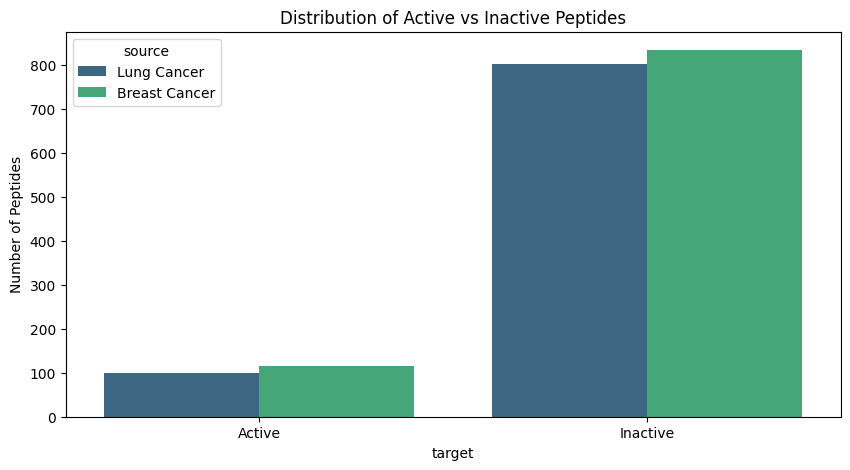

In [ ]:
# Plot Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_all, x='target', hue='source', palette='viridis')
plt.title('Distribution of Active vs Inactive Peptides')
plt.ylabel('Number of Peptides')
plt.show()

## **Sequence Length Distribution**

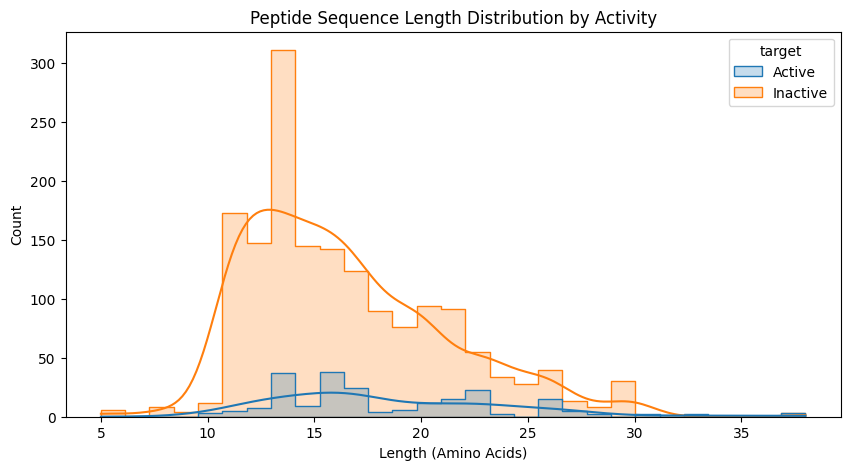

In [ ]:
# Plot Sequence Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_all, x='length', hue='target', kde=True, element="step")
plt.title('Peptide Sequence Length Distribution by Activity')
plt.xlabel('Length (Amino Acids)')
plt.show()

## **Visualizing Sequence Length "Outliers"**

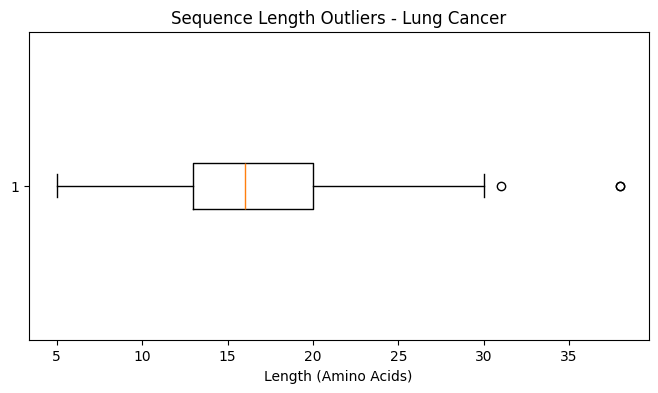

Sequences shorter than 4 residues: 0


In [ ]:
import matplotlib.pyplot as plt

def plot_length_outliers(df, title):
    lengths = df['sequence'].str.len()

    plt.figure(figsize=(8, 4))
    plt.boxplot(lengths, vert=False)
    plt.title(f'Sequence Length Outliers - {title}')
    plt.xlabel('Length (Amino Acids)')
    plt.show()

    # Statistical check for "missing" context (too short to be a peptide)
    too_short = df[df['sequence'].str.len() < 4]
    print(f"Sequences shorter than 4 residues: {len(too_short)}")

plot_length_outliers(df_lung, "Lung Cancer")

## **Amino Acid Composition Analysis**

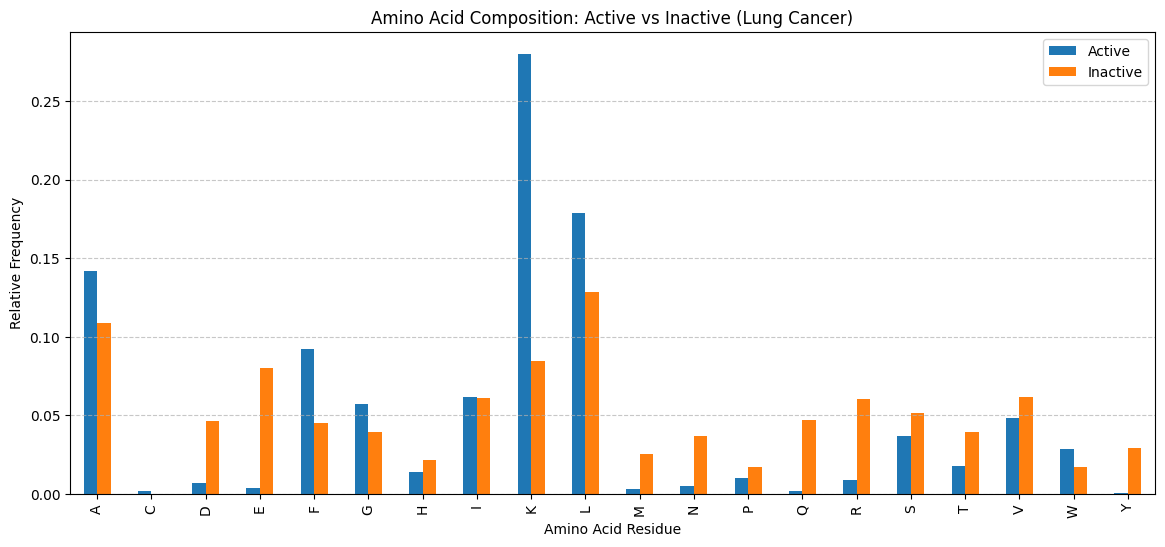

In [ ]:
def get_aa_composition(sequences):
    all_aas = "".join(sequences)
    counts = Counter(all_aas)
    total = sum(counts.values())
    return {aa: count/total for aa, count in sorted(counts.items())}

# Compare AA composition for Lung Cancer dataset
lung_active_aa = get_aa_composition(df_lung_proc[df_lung_proc['target'] == 'Active']['sequence'])
lung_inactive_aa = get_aa_composition(df_lung_proc[df_lung_proc['target'] == 'Inactive']['sequence'])

aa_comparison_df = pd.DataFrame([lung_active_aa, lung_inactive_aa], index=['Active', 'Inactive']).T

aa_comparison_df.plot(kind='bar', figsize=(14, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Amino Acid Composition: Active vs Inactive (Lung Cancer)')
plt.ylabel('Relative Frequency')
plt.xlabel('Amino Acid Residue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Dataset Overlap Check**

In [ ]:
lung_seqs = set(df_lung['sequence'])
breast_seqs = set(df_breast['sequence'])
overlap = lung_seqs.intersection(breast_seqs)

print(f"Total Unique Sequences (Combined): {len(lung_seqs.union(breast_seqs))}")
print(f"Overlapping Sequences between Lung and Breast: {len(overlap)}")

Total Unique Sequences (Combined): 971
Overlapping Sequences between Lung and Breast: 879


## **Checking Duplicate Rows**

In [ ]:
# Returns the total number of duplicate rows
duplicate_count = df_all.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


# **Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Extraction: Amino Acid Composition (AAC)
def get_aac(seq):
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    return [seq.count(aa) / len(seq) for aa in amino_acids]

# Apply extraction
X = np.array([get_aac(s) for s in df_all['sequence']])
y = LabelEncoder().fit_transform(df_all['target']) # Active=0, Inactive=1 (check order)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Training**

## **Training & Evaluating Models**


==================== Random Forest ====================
              precision    recall  f1-score   support

           0       0.87      0.63      0.73        41
           1       0.96      0.99      0.97       329

    accuracy                           0.95       370
   macro avg       0.91      0.81      0.85       370
weighted avg       0.95      0.95      0.95       370



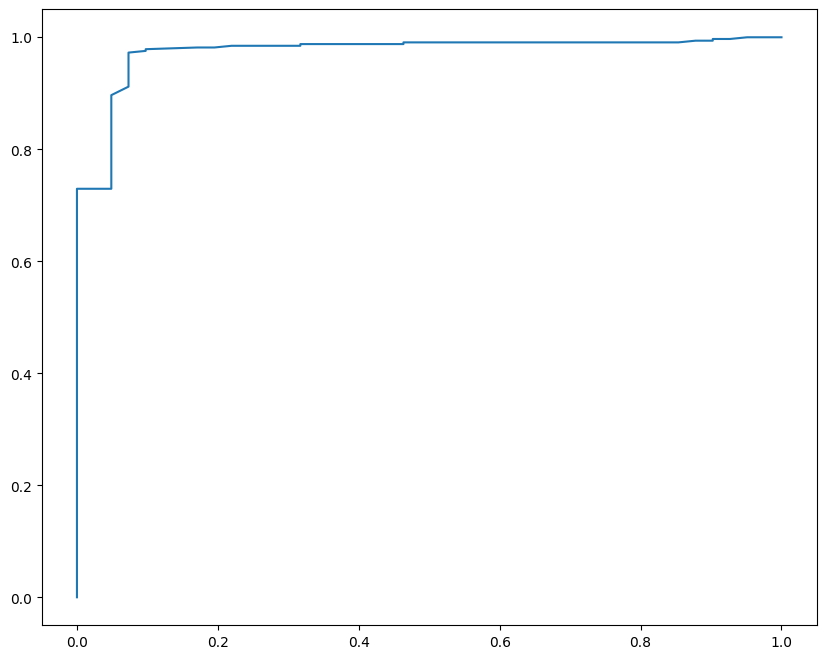

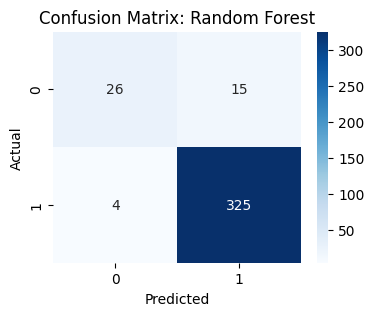


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.40      0.05      0.09        41
           1       0.89      0.99      0.94       329

    accuracy                           0.89       370
   macro avg       0.65      0.52      0.51       370
weighted avg       0.84      0.89      0.85       370



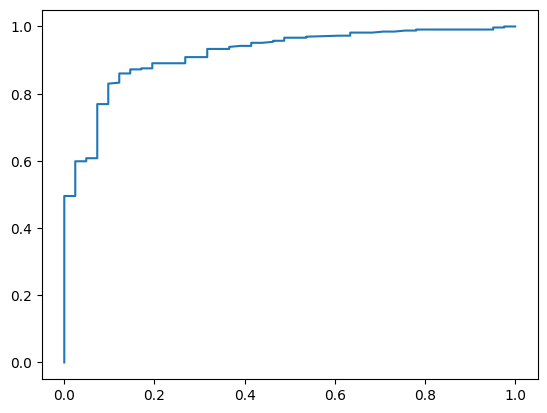

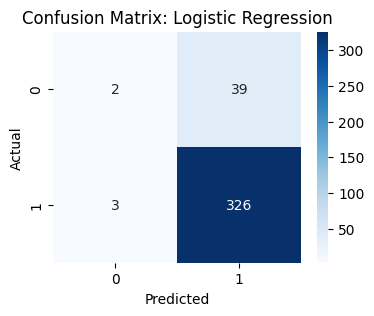


==================== SVM ====================
              precision    recall  f1-score   support

           0       0.70      0.34      0.46        41
           1       0.92      0.98      0.95       329

    accuracy                           0.91       370
   macro avg       0.81      0.66      0.71       370
weighted avg       0.90      0.91      0.90       370



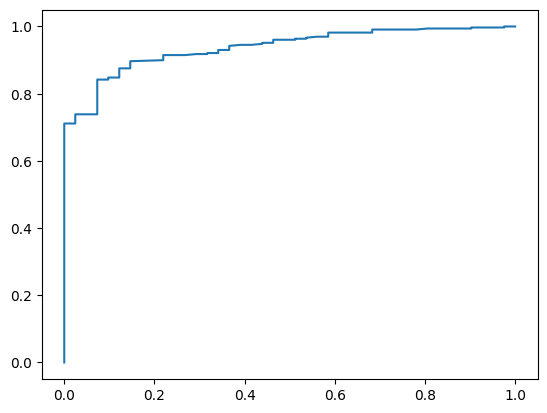

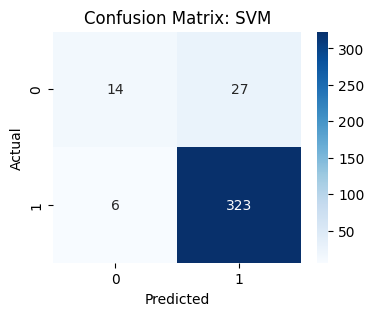

/tmp/ipython-input-3633942170.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


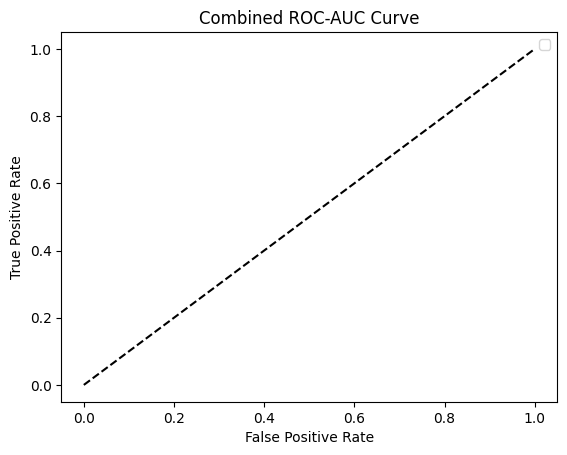

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Timing Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Timing Test
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_probs = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probs),
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }
    results.append(metrics)

    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC-AUC']:.2f})")

    # Print Classification Report
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Plotting
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Finalizing ROC Plot
plt.figure(1) # Go back to ROC figure
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC-AUC Curve')
plt.legend()
plt.show()

## **Summarized Evaluation Metrics**

In [ ]:
summary_df = pd.DataFrame(results)
print("\n### Final Model Comparison ###")
print(summary_df.to_string(index=False))


### Final Model Comparison ###
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Train Time (s)  Test Time (s)
      Random Forest  0.948649   0.955882 0.987842  0.971599 0.974275        0.539539       0.018872
Logistic Regression  0.886486   0.893151 0.990881  0.939481 0.918749        0.080661       0.004666
                SVM  0.910811   0.922857 0.981763  0.951399 0.937134        0.272600       0.034124
